# GeoSosEkon: Provincial Poverty Rate Forecasting (2025-2026)

This notebook implements the forecasting module using Random Forest, XGBoost, and LightGBM ensemble models. The target variable is the average provincial poverty rate (`poverty_rate`). Predictions are projected for 2025 and 2026.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / 'data_bps_datmin.csv'
OUTPUT_DIR = Path('forecast_output')
OUTPUT_DIR.mkdir(exist_ok=True)
sns.set_style('whitegrid')
import joblib

## Data Loading and Preprocessing

In [50]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = ['province', 'year', 'aps_1315', 'aps_1618', 'aps_1924', 'tpt_feb', 'tpt_aug', 'tpak_feb', 'tpak_aug', 'poverty_line_march', 'poverty_line_september', 'poor_population_march', 'poor_population_september', 'poverty_pct_march', 'poverty_pct_september', 'hdi', 'mean_years_schooling', 'expected_years_schooling']
df = df_raw.copy()
df['poverty_rate'] = (df['poverty_pct_march'] + df['poverty_pct_september']) / 2
df['tpt'] = (df['tpt_feb'] + df['tpt_aug']) / 2
df['tpak'] = (df['tpak_feb'] + df['tpak_aug']) / 2
df['poverty_line'] = (df['poverty_line_march'] + df['poverty_line_september']) / 2
df['log_poverty_line'] = np.log(df['poverty_line'])
df['province'] = df['province'].str.strip().str.upper()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   province                   151 non-null    object 
 1   year                       151 non-null    int64  
 2   aps_1315                   151 non-null    float64
 3   aps_1618                   151 non-null    float64
 4   aps_1924                   151 non-null    float64
 5   tpt_feb                    151 non-null    float64
 6   tpt_aug                    151 non-null    float64
 7   tpak_feb                   151 non-null    float64
 8   tpak_aug                   151 non-null    float64
 9   poverty_line_march         151 non-null    int64  
 10  poverty_line_september     151 non-null    int64  
 11  poor_population_march      151 non-null    float64
 12  poor_population_september  151 non-null    float64
 13  poverty_pct_march          151 non-null    float64

## Temporal Exploratory Data Analysis

In [51]:
import plotly.express as px
mean_trend = df.groupby('year')['poverty_rate'].mean()
fig = px.line(mean_trend.reset_index(), x='year', y='poverty_rate', markers=True)
fig.update_traces(line_color='navy', line_width=3, marker=dict(size=10))
fig.update_layout(title="National Average Poverty Rate Trend (2021-2024)", xaxis_title="Year", yaxis_title="Poverty Rate (%)", xaxis=dict(dtick=1))
fig.write_json(OUTPUT_DIR / 'plot_forecast_average_trend.json')
fig.show()

In [52]:
import plotly.express as px
mean_trend = df.groupby('year')['poverty_rate'].mean()
fig = px.line(df.sort_values('year'), x='year', y='poverty_rate', color='province', color_discrete_sequence=['lightgray'])
fig.update_traces(line_width=1, opacity=0.6)
fig.add_scatter(x=mean_trend.index, y=mean_trend.values, mode='lines+markers', line=dict(color='red', width=4), marker=dict(size=10), name='National Average')
fig.update_layout(title="Provincial Poverty Rate Spaghetti Plot (2021-2024)", xaxis_title="Year", yaxis_title="Poverty Rate (%)", showlegend=False, xaxis=dict(dtick=1))
fig.write_json(OUTPUT_DIR / 'plot_forecast_spaghetti.json')
fig.show()

## Feature Engineering: Lag-1 Features

In [53]:
df = df.sort_values(['province', 'year']).reset_index(drop=True)
lag_features = ['poverty_rate', 'hdi', 'tpt', 'tpak', 'aps_1315', 'mean_years_schooling', 'expected_years_schooling', 'log_poverty_line']
for col in lag_features:
    df[f'{col}_lag1'] = df.groupby('province')[col].shift(1)
df_model = df.dropna().copy()
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113 entries, 1 to 150
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   province                       113 non-null    object 
 1   year                           113 non-null    int64  
 2   aps_1315                       113 non-null    float64
 3   aps_1618                       113 non-null    float64
 4   aps_1924                       113 non-null    float64
 5   tpt_feb                        113 non-null    float64
 6   tpt_aug                        113 non-null    float64
 7   tpak_feb                       113 non-null    float64
 8   tpak_aug                       113 non-null    float64
 9   poverty_line_march             113 non-null    int64  
 10  poverty_line_september         113 non-null    int64  
 11  poor_population_march          113 non-null    float64
 12  poor_population_september      113 non-null    float64


## Model Validation Setup

In [54]:
features = [f'{col}_lag1' for col in lag_features]
target = 'poverty_rate'
train_mask = df_model['year'].isin([2022, 2023])
val_mask = df_model['year'] == 2024
X_train, y_train = (df_model.loc[train_mask, features], df_model.loc[train_mask, target])
X_val, y_val = (df_model.loc[val_mask, features], df_model.loc[val_mask, target])
print('Train size:', X_train.shape)
print('Val size:', X_val.shape)

Train size: (75, 8)
Val size: (38, 8)


## Hyperparameter Tuning and Evaluation

In [55]:
rf_grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid={'n_estimators': [50, 100, 150], 'max_depth': [3, 5, 7, None], 'min_samples_split': [2, 5, 10]}, cv=5, scoring='neg_mean_squared_error', n_jobs=1)
rf_grid_search.fit(X_train, y_train)
rf_best = rf_grid_search.best_estimator_
pred_rf = rf_best.predict(X_val)
rmse_rf = np.sqrt(mean_squared_error(y_val, pred_rf))
mae_rf = mean_absolute_error(y_val, pred_rf)
mape_rf = mean_absolute_percentage_error(y_val, pred_rf) * 100
print('Best RF Params:', rf_grid_search.best_params_)
print('RF Val RMSE:', rmse_rf)
print('RF Val MAE:', mae_rf)
print('RF Val MAPE:', mape_rf)

Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
RF Val RMSE: 1.2202117801247718
RF Val MAE: 0.5727855263157903
RF Val MAPE: 3.858166596229001


In [56]:
xgb_grid_search = GridSearchCV(estimator=XGBRegressor(random_state=42), param_grid={'n_estimators': [50, 100, 150], 'max_depth': [3, 4, 5], 'learning_rate': [0.01, 0.05, 0.1]}, cv=5, scoring='neg_mean_squared_error', n_jobs=1)
xgb_grid_search.fit(X_train, y_train)
xgb_best = xgb_grid_search.best_estimator_
pred_xgb = xgb_best.predict(X_val)
rmse_xgb = np.sqrt(mean_squared_error(y_val, pred_xgb))
mae_xgb = mean_absolute_error(y_val, pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_val, pred_xgb) * 100
print('Best XGB Params:', xgb_grid_search.best_params_)
print('XGB Val RMSE:', rmse_xgb)
print('XGB Val MAE:', mae_xgb)
print('XGB Val MAPE:', mape_xgb)

Best XGB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
XGB Val RMSE: 1.52676187600464
XGB Val MAE: 0.7494574125189527
XGB Val MAPE: 4.7195284435019715


In [57]:
lgb_grid_search = GridSearchCV(estimator=LGBMRegressor(random_state=42, verbose=-1), param_grid={'n_estimators': [50, 100, 150], 'max_depth': [3, 4, 5], 'learning_rate': [0.01, 0.05, 0.1], 'num_leaves': [7, 15]}, cv=5, scoring='neg_mean_squared_error', n_jobs=1)
lgb_grid_search.fit(X_train, y_train)
lgb_best = lgb_grid_search.best_estimator_
pred_lgb = lgb_best.predict(X_val)
rmse_lgb = np.sqrt(mean_squared_error(y_val, pred_lgb))
mae_lgb = mean_absolute_error(y_val, pred_lgb)
mape_lgb = mean_absolute_percentage_error(y_val, pred_lgb) * 100
print('Best LGB Params:', lgb_grid_search.best_params_)
print('LGB Val RMSE:', rmse_lgb)
print('LGB Val MAE:', mae_lgb)
print('LGB Val MAPE:', mape_lgb)

Best LGB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150, 'num_leaves': 7}
LGB Val RMSE: 2.247623153506181
LGB Val MAE: 1.3934038120442933
LGB Val MAPE: 12.547180540124028


## Ensemble Weights and Validation

In [58]:
inv_rmse_rf = 1.0 / rmse_rf
inv_rmse_xgb = 1.0 / rmse_xgb
inv_rmse_lgb = 1.0 / rmse_lgb
total_inv = inv_rmse_rf + inv_rmse_xgb + inv_rmse_lgb
w_rf = inv_rmse_rf / total_inv
w_xgb = inv_rmse_xgb / total_inv
w_lgb = inv_rmse_lgb / total_inv
print('RF weight:', w_rf)
print('XGB weight:', w_xgb)
print('LGB weight:', w_lgb)
pred_ens = w_rf * pred_rf + w_xgb * pred_xgb + w_lgb * pred_lgb
rmse_ens = np.sqrt(mean_squared_error(y_val, pred_ens))
mae_ens = mean_absolute_error(y_val, pred_ens)
mape_ens = mean_absolute_percentage_error(y_val, pred_ens) * 100
print('Ensemble Val RMSE:', rmse_ens)
print('Ensemble Val MAE:', mae_ens)
print('Ensemble Val MAPE:', mape_ens)

RF weight: 0.4269662747777178
XGB weight: 0.34123807149490165
LGB weight: 0.2317956537273804
Ensemble Val RMSE: 1.4608533594315036
Ensemble Val MAE: 0.6589954706660616
Ensemble Val MAPE: 4.569805889428637


## Full Model Training

In [59]:
X_all = df_model[features]
y_all = df_model[target]
rf_full = RandomForestRegressor(**rf_grid_search.best_params_, random_state=42)
rf_full.fit(X_all, y_all)
xgb_full = XGBRegressor(**xgb_grid_search.best_params_, random_state=42)
xgb_full.fit(X_all, y_all)
lgb_full = LGBMRegressor(**lgb_grid_search.best_params_, random_state=42, verbose=-1)
lgb_full.fit(X_all, y_all)

,boosting_type,'gbdt'
,num_leaves,7
,max_depth,3
,learning_rate,0.1
,n_estimators,150
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Predictor Extrapolation

In [60]:
extrapolated = []
features_to_extrapolate = ['hdi', 'tpt', 'tpak', 'aps_1315', 'mean_years_schooling', 'expected_years_schooling', 'log_poverty_line']
provinces = df['province'].unique()
for prov in provinces:
    prov_df = df[df['province'] == prov].dropna(subset=features_to_extrapolate)
    prov_dict_2025 = {'province': prov, 'year': 2025}
    prov_dict_2026 = {'province': prov, 'year': 2026}
    for feat in features_to_extrapolate:
        X_t = prov_df[['year']].values
        y_t = prov_df[feat].values
        lr = LinearRegression()
        lr.fit(X_t, y_t)
        prov_dict_2025[feat] = lr.predict([[2025]])[0]
        prov_dict_2026[feat] = lr.predict([[2026]])[0]
    extrapolated.append(prov_dict_2025)
    extrapolated.append(prov_dict_2026)
df_extrapolated = pd.DataFrame(extrapolated)
df_extrapolated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   province                  76 non-null     object 
 1   year                      76 non-null     int64  
 2   hdi                       76 non-null     float64
 3   tpt                       76 non-null     float64
 4   tpak                      76 non-null     float64
 5   aps_1315                  76 non-null     float64
 6   mean_years_schooling      76 non-null     float64
 7   expected_years_schooling  76 non-null     float64
 8   log_poverty_line          76 non-null     float64
dtypes: float64(7), int64(1), object(1)
memory usage: 5.5+ KB


## Recursive Autoregressive Panel Forecasting

In [61]:
forecast_results = []
for prov in provinces:
    prov_2024 = df[(df['province'] == prov) & (df['year'] == 2024)].iloc[0]
    x_2025 = pd.DataFrame([{'poverty_rate_lag1': prov_2024['poverty_rate'], 'hdi_lag1': prov_2024['hdi'], 'tpt_lag1': prov_2024['tpt'], 'tpak_lag1': prov_2024['tpak'], 'aps_1315_lag1': prov_2024['aps_1315'], 'mean_years_schooling_lag1': prov_2024['mean_years_schooling'], 'expected_years_schooling_lag1': prov_2024['expected_years_schooling'], 'log_poverty_line_lag1': prov_2024['log_poverty_line']}])
    pred_rf_25 = rf_full.predict(x_2025)[0]
    pred_xgb_25 = xgb_full.predict(x_2025)[0]
    pred_lgb_25 = lgb_full.predict(x_2025)[0]
    pred_ens_25 = w_rf * pred_rf_25 + w_xgb * pred_xgb_25 + w_lgb * pred_lgb_25
    forecast_results.append({'province': prov, 'year': 2025, 'poverty_rate': pred_ens_25})
df_forecast_2025 = pd.DataFrame(forecast_results)

In [62]:
forecast_results_2026 = []
for prov in provinces:
    prov_2025_y = df_forecast_2025[df_forecast_2025['province'] == prov]['poverty_rate'].values[0]
    prov_2025_feat = df_extrapolated[(df_extrapolated['province'] == prov) & (df_extrapolated['year'] == 2025)].iloc[0]
    x_2026 = pd.DataFrame([{'poverty_rate_lag1': prov_2025_y, 'hdi_lag1': prov_2025_feat['hdi'], 'tpt_lag1': prov_2025_feat['tpt'], 'tpak_lag1': prov_2025_feat['tpak'], 'aps_1315_lag1': prov_2025_feat['aps_1315'], 'mean_years_schooling_lag1': prov_2025_feat['mean_years_schooling'], 'expected_years_schooling_lag1': prov_2025_feat['expected_years_schooling'], 'log_poverty_line_lag1': prov_2025_feat['log_poverty_line']}])
    pred_rf_26 = rf_full.predict(x_2026)[0]
    pred_xgb_26 = xgb_full.predict(x_2026)[0]
    pred_lgb_26 = lgb_full.predict(x_2026)[0]
    pred_ens_26 = w_rf * pred_rf_26 + w_xgb * pred_xgb_26 + w_lgb * pred_lgb_26
    forecast_results_2026.append({'province': prov, 'year': 2026, 'poverty_rate': pred_ens_26})
df_forecast_2026 = pd.DataFrame(forecast_results_2026)

## Save Forecast Results

In [63]:
df_forecast_all = pd.concat([df_forecast_2025, df_forecast_2026], ignore_index=True)
df_forecast_all.to_csv(OUTPUT_DIR / 'output_forecasting_2025_2026.csv', index=False)
print('Saved forecasting results to forecast_output/output_forecasting_2025_2026.csv')
print(df_forecast_all.head())

Saved forecasting results to forecast_output/output_forecasting_2025_2026.csv
        province  year  poverty_rate
0           ACEH  2025     13.258761
1           BALI  2025      4.109442
2         BANTEN  2025      5.531373
3       BENGKULU  2025     12.947086
4  DI YOGYAKARTA  2025     10.306067


In [64]:
df_historical_short = df[['province', 'year', 'poverty_rate']].copy()
df_combined = pd.concat([df_historical_short, df_forecast_all], ignore_index=True)
df_combined.to_csv(OUTPUT_DIR / 'output_forecasting_historical_prediction.csv', index=False)
print('Saved combined historical and forecasting results to forecast_output/output_forecasting_historical_prediction.csv')
model_artifacts = {'rf_model': rf_full, 'xgb_model': xgb_full, 'lgb_model': lgb_full, 'ensemble_weights': {'rf': w_rf, 'xgb': w_xgb, 'lgb': w_lgb}, 'features': features, 'lag_features': lag_features}
joblib.dump(model_artifacts, OUTPUT_DIR / 'forecasting_models.joblib')
print('Saved trained models and weights to forecast_output/forecasting_models.joblib')

Saved combined historical and forecasting results to forecast_output/output_forecasting_historical_prediction.csv
Saved trained models and weights to forecast_output/forecasting_models.joblib


## SHAP Interpretation for Forecasting

SHAP is used to explain the forecasting model at the global level. This section interprets the weighted ensemble prediction from Random Forest, XGBoost, and LightGBM, using the same ensemble weights obtained from validation RMSE. The interpretation is predictive, not causal.

In [65]:
def get_shap_values(explainer, data):
    values = explainer.shap_values(data)
    if isinstance(values, list):
        values = values[0]
    return np.asarray(values)

def get_expected_value(explainer):
    value = explainer.expected_value
    if isinstance(value, list):
        value = value[0]
    value = np.asarray(value).reshape(-1)[0]
    return float(value)
rf_explainer = shap.TreeExplainer(rf_full)
xgb_explainer = shap.TreeExplainer(xgb_full)
lgb_explainer = shap.TreeExplainer(lgb_full)
shap_rf_val = get_shap_values(rf_explainer, X_val)
shap_xgb_val = get_shap_values(xgb_explainer, X_val)
shap_lgb_val = get_shap_values(lgb_explainer, X_val)
shap_ensemble_val = w_rf * shap_rf_val + w_xgb * shap_xgb_val + w_lgb * shap_lgb_val
ensemble_base_value = w_rf * get_expected_value(rf_explainer) + w_xgb * get_expected_value(xgb_explainer) + w_lgb * get_expected_value(lgb_explainer)
print('Validation SHAP shape:', shap_ensemble_val.shape)
print('Validation feature shape:', X_val.shape)

Validation SHAP shape: (38, 8)
Validation feature shape: (38, 8)


In [66]:
df_shap_global = pd.DataFrame({'feature': features, 'mean_abs_shap': np.abs(shap_ensemble_val).mean(axis=0), 'mean_shap': shap_ensemble_val.mean(axis=0)}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
df_shap_global['rank'] = np.arange(1, len(df_shap_global) + 1)
df_shap_global.to_csv(OUTPUT_DIR / 'output_shap_global_importance.csv', index=False)
df_shap_global

,feature,mean_abs_shap,mean_shap,rank
0,poverty_rate_lag1,4.566310,-0.021702,1
1,hdi_lag1,0.371998,-0.044936,2
2,expected_years_schooling_lag1,0.085477,-0.020889,3
3,aps_1315_lag1,0.074448,-0.003503,4
4,log_poverty_line_lag1,0.058494,0.000974,5
5,mean_years_schooling_lag1,0.044925,-0.012799,6
6,tpt_lag1,0.043712,-0.019476,7
7,tpak_lag1,0.035535,-0.004480,8


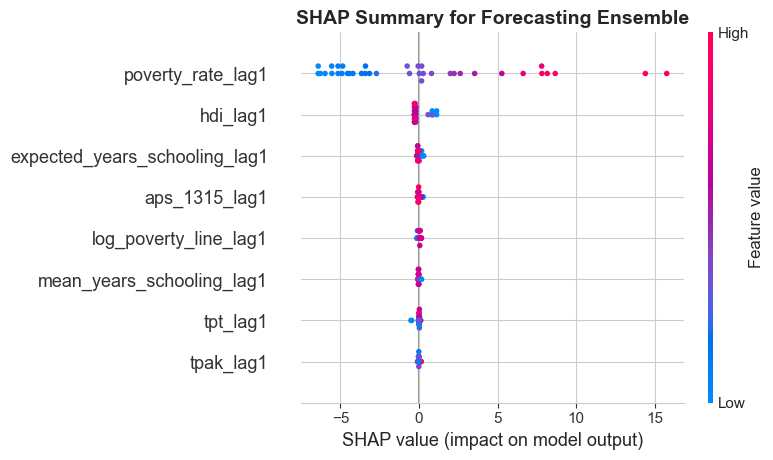

In [67]:
import plotly.express as px
df_shap_global_sorted = df_shap_global.sort_values('mean_abs_shap', ascending=True)
fig = px.bar(df_shap_global_sorted, x='mean_abs_shap', y='feature', orientation='h', title='Global SHAP Feature Importance for Forecasting Ensemble', color_discrete_sequence=['steelblue'])
fig.update_layout(xaxis_title="mean(|SHAP value|) (average impact on model output magnitude)", yaxis_title="")
fig.write_json(OUTPUT_DIR / 'plot_shap_summary_bar.json')
fig.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_ensemble_val, X_val, feature_names=features, show=False)
plt.title('SHAP Summary for Forecasting Ensemble', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_shap_summary_beeswarm.png', bbox_inches='tight')
plt.show()

## SHAP for Forecast Horizon (2025-2026)

This section explains the input conditions used by the ensemble when generating recursive poverty forecasts for 2025 and 2026.

In [68]:
forecast_input_rows = []
for prov in provinces:
    prov_2024 = df[(df['province'] == prov) & (df['year'] == 2024)].iloc[0]
    forecast_input_rows.append({'province': prov, 'year': 2025, 'poverty_rate_lag1': prov_2024['poverty_rate'], 'hdi_lag1': prov_2024['hdi'], 'tpt_lag1': prov_2024['tpt'], 'tpak_lag1': prov_2024['tpak'], 'aps_1315_lag1': prov_2024['aps_1315'], 'mean_years_schooling_lag1': prov_2024['mean_years_schooling'], 'expected_years_schooling_lag1': prov_2024['expected_years_schooling'], 'log_poverty_line_lag1': prov_2024['log_poverty_line']})
    prov_2025_y = df_forecast_2025[df_forecast_2025['province'] == prov]['poverty_rate'].values[0]
    prov_2025_feat = df_extrapolated[(df_extrapolated['province'] == prov) & (df_extrapolated['year'] == 2025)].iloc[0]
    forecast_input_rows.append({'province': prov, 'year': 2026, 'poverty_rate_lag1': prov_2025_y, 'hdi_lag1': prov_2025_feat['hdi'], 'tpt_lag1': prov_2025_feat['tpt'], 'tpak_lag1': prov_2025_feat['tpak'], 'aps_1315_lag1': prov_2025_feat['aps_1315'], 'mean_years_schooling_lag1': prov_2025_feat['mean_years_schooling'], 'expected_years_schooling_lag1': prov_2025_feat['expected_years_schooling'], 'log_poverty_line_lag1': prov_2025_feat['log_poverty_line']})
df_forecast_input = pd.DataFrame(forecast_input_rows)
X_forecast = df_forecast_input[features]
shap_rf_forecast = get_shap_values(rf_explainer, X_forecast)
shap_xgb_forecast = get_shap_values(xgb_explainer, X_forecast)
shap_lgb_forecast = get_shap_values(lgb_explainer, X_forecast)
shap_ensemble_forecast = w_rf * shap_rf_forecast + w_xgb * shap_xgb_forecast + w_lgb * shap_lgb_forecast
print('Forecast SHAP shape:', shap_ensemble_forecast.shape)
print('Forecast feature shape:', X_forecast.shape)

Forecast SHAP shape: (76, 8)
Forecast feature shape: (76, 8)


In [69]:
forecast_prediction_lookup = df_forecast_all.set_index(['province', 'year'])['poverty_rate']
forecast_shap_records = []
for row_idx, row in df_forecast_input.iterrows():
    prediction = forecast_prediction_lookup.loc[row['province'], row['year']]
    for feature_idx, feature in enumerate(features):
        forecast_shap_records.append({'province': row['province'], 'year': row['year'], 'feature': feature, 'feature_value': row[feature], 'shap_value': shap_ensemble_forecast[row_idx, feature_idx], 'abs_shap': abs(shap_ensemble_forecast[row_idx, feature_idx]), 'ensemble_base_value': ensemble_base_value, 'y_predicted': prediction})
df_shap_forecast = pd.DataFrame(forecast_shap_records)
df_shap_forecast.to_csv(OUTPUT_DIR / 'output_shap_per_province_2025_2026.csv', index=False)
df_shap_forecast_importance = df_shap_forecast.groupby('feature', as_index=False).agg(mean_abs_shap=('abs_shap', 'mean'), mean_shap=('shap_value', 'mean')).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
df_shap_forecast_importance['rank'] = np.arange(1, len(df_shap_forecast_importance) + 1)
df_shap_forecast_importance.to_csv(OUTPUT_DIR / 'output_shap_forecast_importance.csv', index=False)
df_shap_forecast_importance

,feature,mean_abs_shap,mean_shap,rank
0,poverty_rate_lag1,4.479818,-0.392091,1
1,hdi_lag1,0.362207,-0.059855,2
2,aps_1315_lag1,0.071948,-0.002042,3
3,expected_years_schooling_lag1,0.068415,-0.038483,4
4,log_poverty_line_lag1,0.060996,0.017584,5
5,mean_years_schooling_lag1,0.040812,-0.025794,6
6,tpak_lag1,0.035570,-0.000560,7
7,tpt_lag1,0.021584,0.004390,8


In [70]:
import plotly.express as px
fig = px.bar(df_shap_forecast_importance.sort_values('mean_abs_shap', ascending=True), x='mean_abs_shap', y='feature', orientation='h', title='Forecast Horizon SHAP Feature Importance (2025-2026)', color_discrete_sequence=['steelblue'])
fig.update_layout(xaxis_title="Mean Absolute SHAP Value", yaxis_title="")
fig.write_json(OUTPUT_DIR / 'plot_shap_forecast_importance.json')
fig.show()

## Cluster-Level SHAP Interpretation

Cluster-level SHAP will be added after Layer 1 produces the final provincial cluster labels. The planned output is a cluster-wise aggregation of forecast SHAP values to compare dominant poverty drivers across socioeconomic province typologies.

In [71]:
import plotly.express as px
cluster_df = pd.read_csv(PROJECT_ROOT / 'LAYER 1 - CLUSTERING' / 'cluster_output' / 'output_province_clusters.csv')
cluster_df = cluster_df[['PROVINSI', 'cluster_label']].drop_duplicates(subset=['PROVINSI'], keep='last').rename(columns={'PROVINSI': 'province'})

df_forecast_input['cluster_label'] = df_forecast_input['province'].map(cluster_df.set_index('province')['cluster_label'])

for cluster in df_forecast_input['cluster_label'].dropna().unique():
    cluster_indices = df_forecast_input.index[df_forecast_input['cluster_label'] == cluster].tolist()
    cluster_indices = [i for i in cluster_indices if i < shap_ensemble_forecast.shape[0]]
    if not cluster_indices:
        continue
        
    shap_cluster = shap_ensemble_forecast[cluster_indices, :]
    df_shap_c = pd.DataFrame({'feature': features, 'mean_abs_shap': np.abs(shap_cluster).mean(axis=0)}).sort_values('mean_abs_shap', ascending=True)
    
    fig = px.bar(df_shap_c, x='mean_abs_shap', y='feature', orientation='h', title=f'SHAP Feature Importance for Cluster {cluster.split()[-1]} (2025-2026)', color_discrete_sequence=['steelblue'])
    fig.update_layout(xaxis_title="mean(|SHAP value|)", yaxis_title="")
    fig.write_json(OUTPUT_DIR / f'plot_shap_forecast_cluster_{cluster.split()[-1]}.json')
    fig.show()

## Visualization of Historical and Forecast Trends

In [72]:
import plotly.graph_objects as go
combined_mean = df_combined.groupby('year')['poverty_rate'].mean()
fig = go.Figure()
fig.add_trace(go.Scatter(x=combined_mean.index[:4], y=combined_mean.values[:4], mode='lines+markers', name='Historical (2021-2024)', line=dict(color='blue', width=3)))
fig.add_trace(go.Scatter(x=combined_mean.index[3:], y=combined_mean.values[3:], mode='lines+markers', name='Forecast (2024-2026)', line=dict(color='red', width=3, dash='dash')))
fig.update_layout(title="Indonesia Average Poverty Rate Historical & Projections", xaxis_title="Year", yaxis_title="Poverty Rate (%)", xaxis=dict(dtick=1))
fig.write_json(OUTPUT_DIR / 'plot_forecast_combined_trend.json')
fig.show()